Name:Dhokare Harshad Santosh(202401110024)
     Vinay Sandip Dhake(202401110031)
     Sudarshan Sakharam Bansude(202401110043)

# Practical Assignment 1: Plant Leaf Disease Classification using CNN and MobileNetV2

**Goal:** Compare a Custom CNN trained from scratch with MobileNetV2 using transfer learning and fine-tuning.

**Dataset:** PlantVillage  
**Selected classes:**  
1. Tomato Early Blight  
2. Tomato Late Blight  
3. Tomato Healthy  
4. Potato Early Blight  

This updated notebook improves the Custom CNN training pipeline while keeping the MobileNetV2 comparison.


## 1. Research Question

**Can MobileNetV2 transfer learning and fine-tuning achieve better plant-leaf disease classification performance than a CNN trained from scratch?**

We use the same dataset split and test set for all approaches so that the comparison remains fair.


In [1]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import glob
import random
import time
import zipfile
import shutil
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Task 2 – Model 1: Custom CNN

The first model is trained completely from scratch.

### Architecture

```text
Input
 ↓
Data Augmentation
 ↓
Rescaling
 ↓
Conv2D 32
 ↓
MaxPooling
 ↓
Conv2D 64
 ↓
MaxPooling
 ↓
Conv2D 128
 ↓
MaxPooling
 ↓
Global Average Pooling
 ↓
Dense 128
 ↓
Dropout
 ↓
Softmax – 4 classes
```

## 3. Configuration

We use 4 balanced classes with a maximum of 500 images per class, giving up to 2,000 images total.


In [2]:
# ============================================================
# 3. CONFIGURATION
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
MAX_PER_CLASS = 500

CLASS_NAMES = [
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy",
    "Potato___Early_blight"
]

LABEL_MAP = {
    name: i for i, name in enumerate(CLASS_NAMES)
}

print("Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)


Classes:
0 -> Tomato___Early_blight
1 -> Tomato___Late_blight
2 -> Tomato___healthy
3 -> Potato___Early_blight


## 4. Download PlantVillage Dataset

If the dataset is already present, this cell attempts to reuse it. Otherwise it downloads the PlantVillage archive.


In [3]:
# ============================================================
# 4. DATASET DOWNLOAD / EXTRACTION
# ============================================================

DATA_DIR = "/content/plantvillage_data"
os.makedirs(DATA_DIR, exist_ok=True)

# PlantVillage GitHub archive
ZIP_URL = "https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip"
ZIP_PATH = "/content/plantvillage.zip"

# Download only if needed
if not os.path.exists(ZIP_PATH):
    print("Downloading PlantVillage dataset...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    print("Download complete.")
else:
    print("ZIP already exists. Reusing it.")

EXTRACT_MARKER = os.path.join(DATA_DIR, "_extracted")

if not os.path.exists(EXTRACT_MARKER):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    open(EXTRACT_MARKER, "w").close()
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

# Locate the folder containing the selected class folders
possible_roots = []

for root, dirs, files in os.walk(DATA_DIR):
    if all(cls in dirs for cls in CLASS_NAMES):
        possible_roots.append(root)

if not possible_roots:
    raise FileNotFoundError(
        "Could not find the folder containing all selected classes. "
        "Please inspect the extracted dataset folders."
    )

DATA_ROOT = possible_roots[0]
print("Dataset root:", DATA_ROOT)


Download complete.
Extracting dataset...
Extraction complete.
Dataset root: /content/plantvillage_data/PlantVillage-Dataset-master/raw/color


## 5. Build a Balanced DataFrame

We collect up to 500 images from each selected class. The resulting DataFrame stores the image path, numeric label, and class name.


In [4]:
# ============================================================
# 5. BUILD DATAFRAME
# ============================================================

records = []

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_ROOT, class_name)

    image_paths = [
        p for p in glob.glob(os.path.join(class_dir, "*"))
        if p.endswith(VALID_EXTENSIONS)
    ]

    image_paths = sorted(image_paths)[:MAX_PER_CLASS]

    print(f"{class_name}: {len(image_paths)} images")

    for path in image_paths:
        records.append({
            "filepath": path,
            "label": LABEL_MAP[class_name],
            "class_name": class_name
        })

dataset_df = pd.DataFrame(records)

print("\nTotal images:", len(dataset_df))
display(dataset_df.head())

print("\nClass distribution:")
display(dataset_df["class_name"].value_counts())


Tomato___Early_blight: 500 images
Tomato___Late_blight: 500 images
Tomato___healthy: 500 images
Potato___Early_blight: 500 images

Total images: 2000


,filepath,label,class_name
0,/content/plantvillage_data/PlantVillage-Datase...,0,Tomato___Early_blight
1,/content/plantvillage_data/PlantVillage-Datase...,0,Tomato___Early_blight
2,/content/plantvillage_data/PlantVillage-Datase...,0,Tomato___Early_blight
3,/content/plantvillage_data/PlantVillage-Datase...,0,Tomato___Early_blight
4,/content/plantvillage_data/PlantVillage-Datase...,0,Tomato___Early_blight



Class distribution:


,count
class_name,
Tomato___Early_blight,500
Tomato___Late_blight,500
Tomato___healthy,500
Potato___Early_blight,500


## 6. Train / Validation / Test Split

We use a stratified split so that all four classes remain represented proportionally:

- 70% training
- 15% validation
- 15% testing


In [5]:
# ============================================================
# 6. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    random_state=SEED,
    stratify=dataset_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

print("\nTraining distribution:")
display(train_df["class_name"].value_counts().sort_index())

print("\nValidation distribution:")
display(val_df["class_name"].value_counts().sort_index())

print("\nTesting distribution:")
display(test_df["class_name"].value_counts().sort_index())


Training: 1400
Validation: 300
Testing: 300

Training distribution:


,count
class_name,
Potato___Early_blight,350
Tomato___Early_blight,350
Tomato___Late_blight,350
Tomato___healthy,350



Validation distribution:


,count
class_name,
Potato___Early_blight,75
Tomato___Early_blight,75
Tomato___Late_blight,75
Tomato___healthy,75



Testing distribution:


,count
class_name,
Potato___Early_blight,75
Tomato___Early_blight,75
Tomato___Late_blight,75
Tomato___healthy,75


## 7. Visualize Sample Images


/tmp/ipykernel_1979/866510982.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(3, len(x)), random_state=SEED))


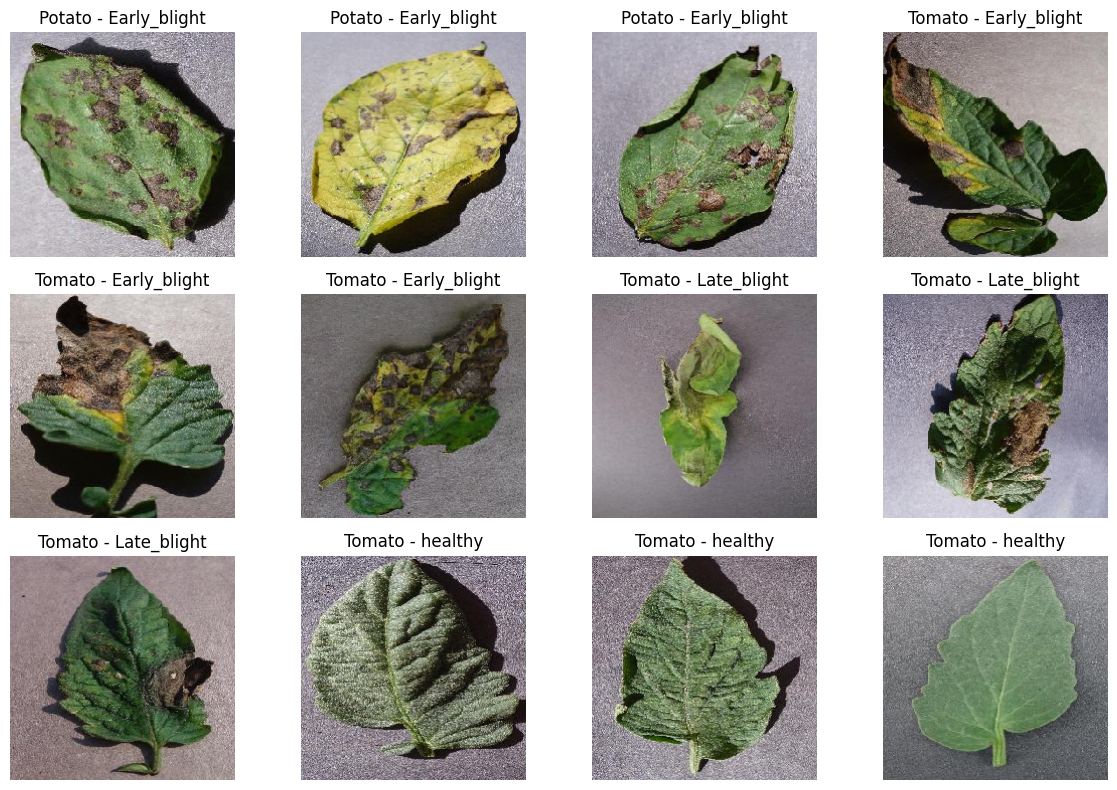

In [6]:
# ============================================================
# 7. VISUALIZE SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12, 8))

sample_df = (
    dataset_df.groupby("class_name", group_keys=False)
    .apply(lambda x: x.sample(min(3, len(x)), random_state=SEED))
    .reset_index(drop=True)
)

for i, row in sample_df.head(12).iterrows():
    img = tf.keras.utils.load_img(row["filepath"], target_size=IMG_SIZE)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(row["class_name"].replace("___", " - "))
    plt.axis("off")

plt.tight_layout()
plt.show()


## 8. Create TensorFlow Input Pipeline

Images are resized to 224×224 and converted into batches. Augmentation is applied **inside the training model**, so validation and test images remain unchanged.


In [7]:
# ============================================================
# 8. TF.DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(
            image,
            channels=3,
            expand_animations=False
        )
        image.set_shape([None, None, 3])
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)

        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Datasets ready.")


Datasets ready.


# 9. Data Augmentation

Augmentation creates realistic variations of training images. We keep it moderate so that disease patterns are not destroyed.


In [8]:
# ============================================================
# 9. DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

print("Data augmentation ready.")


Data augmentation ready.


# 10. IMPROVED CUSTOM CNN

This is the main improvement.

Compared with the original small CNN, this model uses:

- Multiple convolution blocks
- Batch Normalization
- Max Pooling
- Moderate Dropout
- Global Average Pooling
- A larger dense layer
- Data augmentation
- Lower learning rate

The model is still a **CNN trained from scratch**; it does not use ImageNet pretrained weights.


In [9]:
# ============================================================
# 10. IMPROVED CUSTOM CNN
# ============================================================

custom_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(*IMG_SIZE, 3)),

    # Augmentation only during training
    data_augmentation,

    # Scale 0-255 pixels to 0-1
    tf.keras.layers.Rescaling(1.0 / 255.0),

    # -------------------------
    # Block 1
    # -------------------------
    tf.keras.layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.20),

    # -------------------------
    # Block 2
    # -------------------------
    tf.keras.layers.Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # -------------------------
    # Block 3
    # -------------------------
    tf.keras.layers.Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # -------------------------
    # Block 4
    # -------------------------
    tf.keras.layers.Conv2D(
        256, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(
        256, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),

    # -------------------------
    # Classification head
    # -------------------------
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
], name="Improved_Custom_CNN")


custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()


Model: "Improved_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,02

 Total params: 1,243,940 (4.75 MB)

 Trainable params: 1,241,508 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

## 11. Train the Custom CNN

We use EarlyStopping and ReduceLROnPlateau.

- EarlyStopping prevents unnecessary training when validation accuracy stops improving.
- ReduceLROnPlateau lowers the learning rate when validation loss stops improving.


In [10]:
# ============================================================
# 11. TRAIN CUSTOM CNN
# ============================================================

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

start_time = time.time()

history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=cnn_callbacks,
    verbose=1
)

cnn_time = time.time() - start_time

print(f"\nCustom CNN training time: {cnn_time:.2f} seconds")


Epoch 1/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 408ms/step - accuracy: 0.8036 - loss: 0.5374 - val_accuracy: 0.2500 - val_loss: 1.6302 - learning_rate: 3.0000e-04
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 318ms/step - accuracy: 0.8893 - loss: 0.3349 - val_accuracy: 0.2500 - val_loss: 2.1374 - learning_rate: 3.0000e-04
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 320ms/step - accuracy: 0.8850 - loss: 0.3247 - val_accuracy: 0.2500 - val_loss: 2.7445 - learning_rate: 3.0000e-04
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.8773 - loss: 0.3529
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 327ms/step - accuracy: 0.8764 - loss: 0.3379 - val_accuracy: 0.3300 - val_loss: 2.7280 - learning_rate: 3.0000e-04
Epoch 5/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 332ms/step - accuracy: 0.9300 - loss: 0.2093 - val_accuracy: 0.3700 - val_loss: 2.4932 - learning_rate: 1.5000e-04
Epoch 6/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 335ms/step - accuracy:

## 12. Plot Custom CNN Training Curves


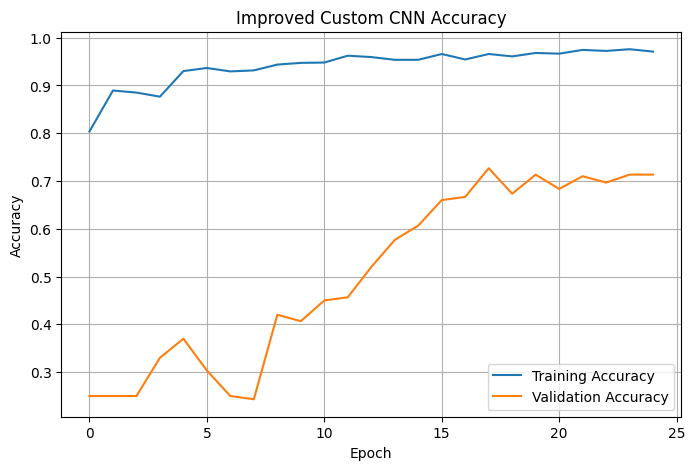

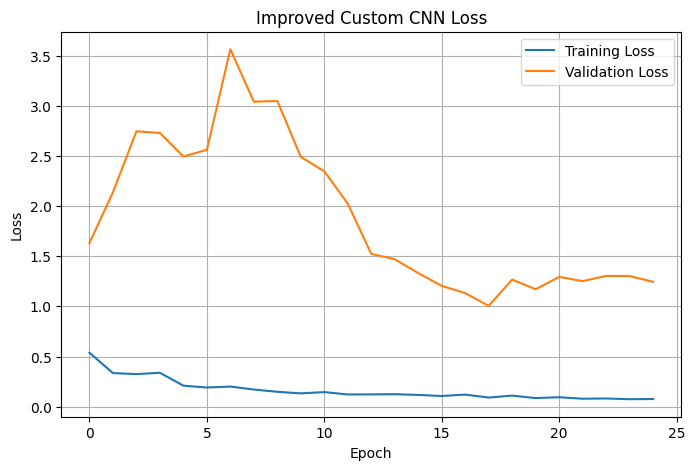

In [11]:
# ============================================================
# 12. CUSTOM CNN TRAINING CURVES
# ============================================================

history_df = pd.DataFrame(history_cnn.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved Custom CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Custom CNN Loss")
plt.legend()
plt.grid(True)
plt.show()


# 13. MobileNetV2 Transfer Learning

MobileNetV2 is used as the pretrained comparison model. Its ImageNet feature extractor is initially frozen, and a new 4-class classification head is trained.


In [12]:
# ============================================================
# 13. MOBILENETV2 - TRANSFER LEARNING
# ============================================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_input = tf.keras.Input(shape=(*IMG_SIZE, 3))

# MobileNetV2 preprocessing: maps pixels to approximately [-1, 1]
x = tf.keras.layers.Lambda(
    tf.keras.applications.mobilenet_v2.preprocess_input
)(mobilenet_input)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
mobilenet_output = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenet_model = tf.keras.Model(
    mobilenet_input,
    mobilenet_output,
    name="MobileNetV2_TransferLearning"
)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 14. Train MobileNetV2 Transfer Learning


In [13]:
# ============================================================
# 14. TRAIN MOBILENETV2 TRANSFER LEARNING
# ============================================================

mobilenet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

start_time = time.time()

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=mobilenet_callbacks,
    verbose=1
)

mobilenet_time = time.time() - start_time

print(f"\nMobileNetV2 transfer-learning time: {mobilenet_time:.2f} seconds")


Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 53s 740ms/step - accuracy: 0.6729 - loss: 0.8360 - val_accuracy: 0.8767 - val_loss: 0.3633 - learning_rate: 0.0010
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8714 - loss: 0.3552 - val_accuracy: 0.8967 - val_loss: 0.2717 - learning_rate: 0.0010
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9121 - loss: 0.2648 - val_accuracy: 0.9200 - val_loss: 0.2290 - learning_rate: 0.0010
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9179 - loss: 0.2273 - val_accuracy: 0.9200 - val_loss: 0.2135 - learning_rate: 0.0010
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9379 - loss: 0.1896 - val_accuracy: 0.9267 - val_loss: 0.2025 - learning_rate: 0.0010
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9436 - loss: 0.1756 - val_accuracy: 0.9433 - val_loss: 0.1768 - learning_rate: 0.0010
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9479 - loss: 0.1493 - val_a

# 15. MobileNetV2 Fine-Tuning

After transfer learning, we unfreeze only the final part of MobileNetV2.

A very small learning rate is used so that pretrained features are adjusted carefully instead of being destroyed.


In [15]:
# ============================================================
# 15. MOBILENETV2 FINE-TUNING
# ============================================================

base_model.trainable = True

# Freeze earlier layers and fine-tune only the last 30 layers.
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNorm layers frozen for stable fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(
    "Trainable MobileNetV2 layers:",
    sum(layer.trainable for layer in base_model.layers)
)


Trainable MobileNetV2 layers: 19


In [16]:
# ============================================================
# 16. TRAIN FINE-TUNED MOBILENETV2
# ============================================================

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1
    )
]

start_time = time.time()

history_finetune = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=fine_tune_callbacks,
    verbose=1
)

finetune_time = time.time() - start_time

print(f"\nMobileNetV2 fine-tuning time: {finetune_time:.2f} seconds")


Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 406ms/step - accuracy: 0.9521 - loss: 0.1359 - val_accuracy: 0.9300 - val_loss: 0.1774 - learning_rate: 1.0000e-05
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9600 - loss: 0.1020 - val_accuracy: 0.9233 - val_loss: 0.2178 - learning_rate: 1.0000e-05
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9693 - loss: 0.0934 - val_accuracy: 0.9433 - val_loss: 0.1592 - learning_rate: 1.0000e-05
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9779 - loss: 0.0666 - val_accuracy: 0.9400 - val_loss: 0.1528 - learning_rate: 1.0000e-05
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9779 - loss: 0.0598 - val_accuracy: 0.9500 - val_loss: 0.1339 - learning_rate: 1.0000e-05
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9893 - loss: 0.0444 - val_accuracy: 0.9533 - val_loss: 0.1428 - learning_rate: 1.0000e-05
Epoch 7/15
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.989

# 17. Evaluation Function

We evaluate models on the **same untouched test set** using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report


In [17]:
# ============================================================
# 17. EVALUATION FUNCTION
# ============================================================

def get_predictions(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions)

    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, dataset, model_name):
    y_true, y_pred = get_predictions(model, dataset)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }


In [18]:
# ============================================================
# 18. EVALUATE ALL MODELS
# ============================================================

cnn_result = evaluate_model(
    custom_cnn,
    test_ds,
    "Improved Custom CNN"
)

mobilenet_result = evaluate_model(
    mobilenet_model,
    test_ds,
    "MobileNetV2 (Transfer Learning + Fine-Tuning)"
)


Improved Custom CNN
Accuracy : 0.7633 (76.33%)
Precision: 0.8345
Recall   : 0.7633
F1 Score : 0.7192

Classification Report:
                       precision    recall  f1-score   support

Tomato___Early_blight       1.00      0.20      0.33        75
 Tomato___Late_blight       0.68      0.91      0.78        75
     Tomato___healthy       0.66      1.00      0.79        75
Potato___Early_blight       1.00      0.95      0.97        75

             accuracy                           0.76       300
            macro avg       0.83      0.76      0.72       300
         weighted avg       0.83      0.76      0.72       300

MobileNetV2 (Transfer Learning + Fine-Tuning)
Accuracy : 0.9700 (97.00%)
Precision: 0.9704
Recall   : 0.9700
F1 Score : 0.9699

Classification Report:
                       precision    recall  f1-score   support

Tomato___Early_blight       0.96      0.92      0.94        75
 Tomato___Late_blight       0.94      0.99      0.96        75
     Tomato___healthy      

# 19. Confusion Matrices


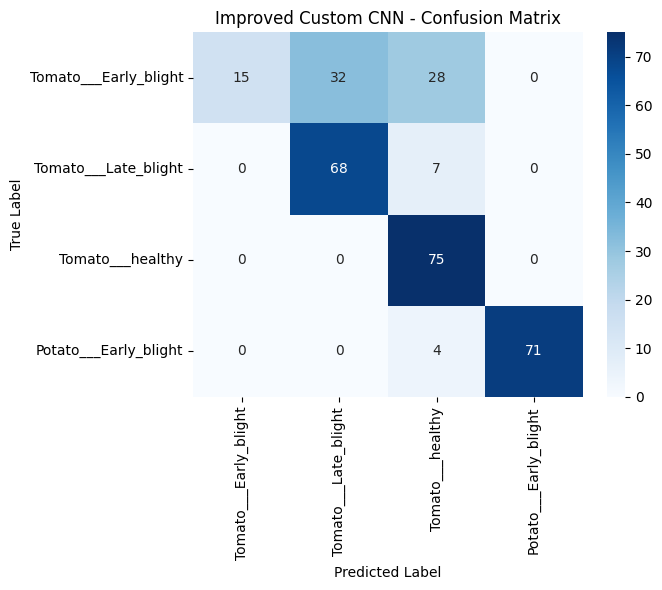

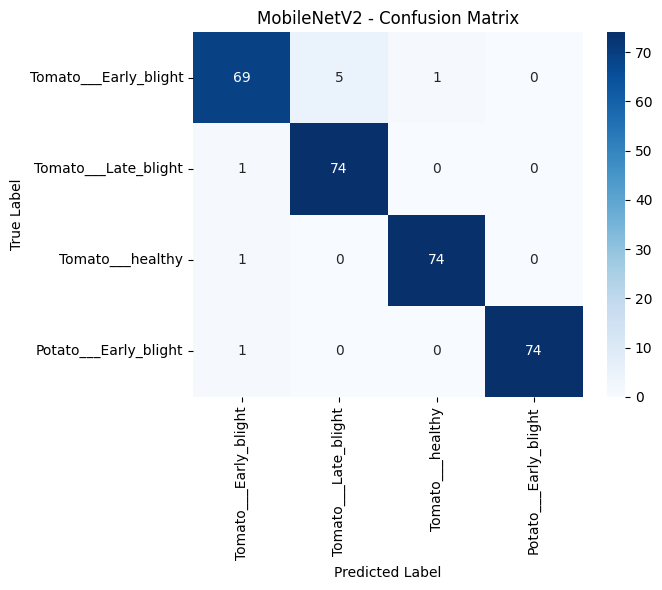

In [19]:
# ============================================================
# 19. CONFUSION MATRICES
# ============================================================

def plot_confusion_matrix(result, title):
    cm = confusion_matrix(
        result["y_true"],
        result["y_pred"]
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    cnn_result,
    "Improved Custom CNN - Confusion Matrix"
)

plot_confusion_matrix(
    mobilenet_result,
    "MobileNetV2 - Confusion Matrix"
)


# 20. Final Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Improved Custom CNN,0.763333,0.834474,0.763333,0.719182,424.952857
1,MobileNetV2 (Transfer Learning + Fine-Tuning),0.970000,0.970427,0.970000,0.969942,173.921892


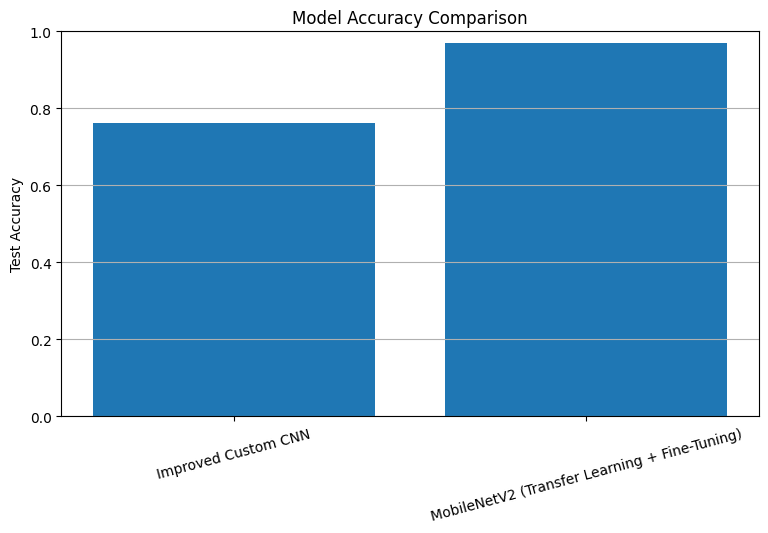

In [20]:
# ============================================================
# 20. FINAL COMPARISON
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Model": cnn_result["Model"],
        "Accuracy": cnn_result["Accuracy"],
        "Precision": cnn_result["Precision"],
        "Recall": cnn_result["Recall"],
        "F1 Score": cnn_result["F1 Score"],
        "Training Time (sec)": cnn_time
    },
    {
        "Model": mobilenet_result["Model"],
        "Accuracy": mobilenet_result["Accuracy"],
        "Precision": mobilenet_result["Precision"],
        "Recall": mobilenet_result["Recall"],
        "F1 Score": mobilenet_result["F1 Score"],
        "Training Time (sec)": mobilenet_time + finetune_time
    }
])

display(comparison_df)

plt.figure(figsize=(9, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()


# 21. Sample Test Predictions

This section shows real test images, the actual class, the predicted class, and whether the prediction is correct.


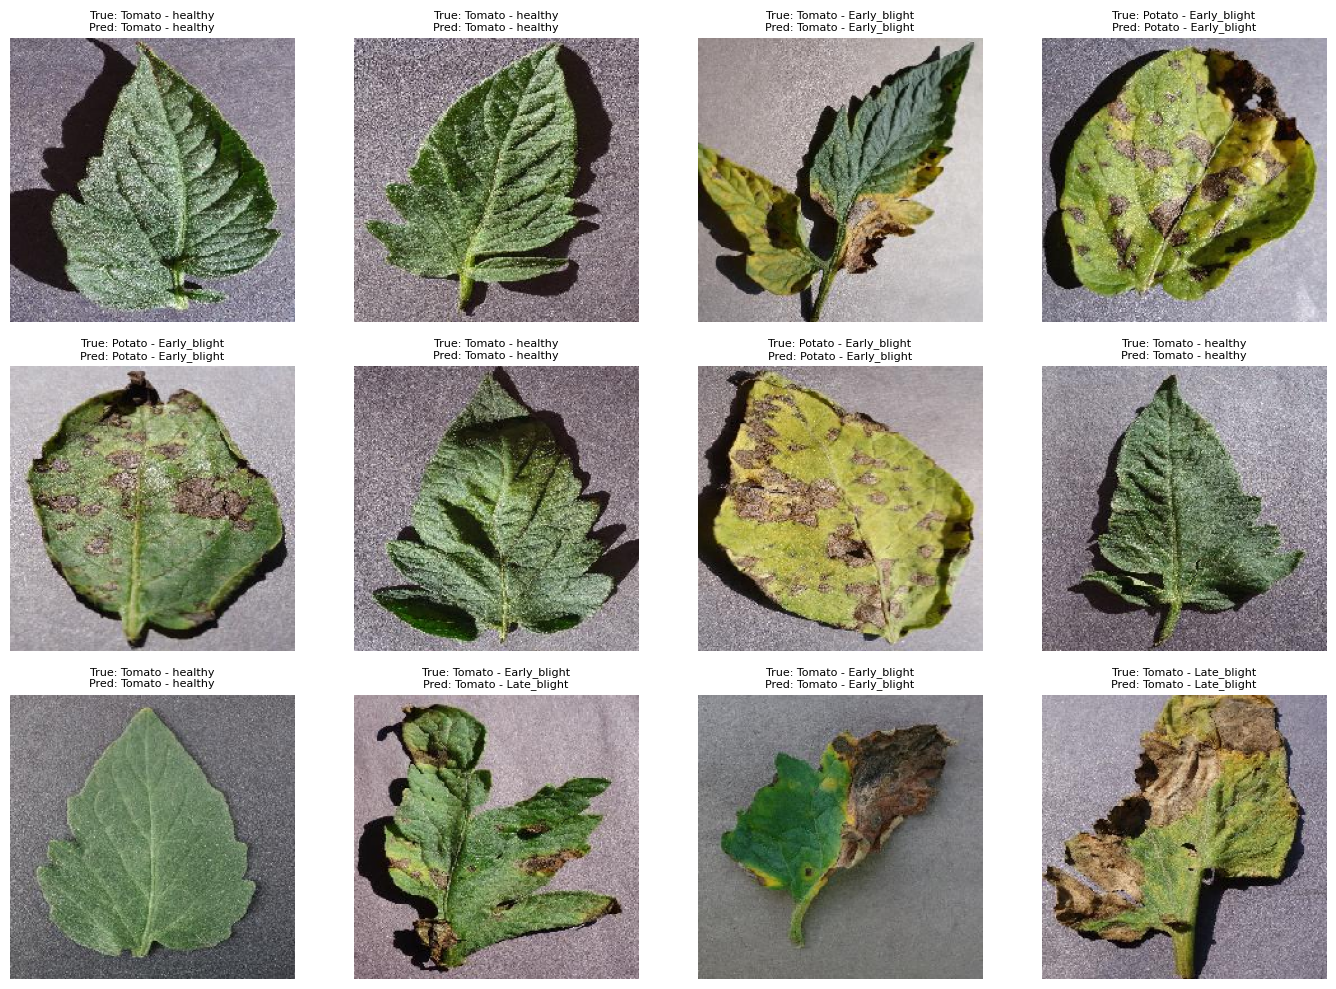

In [21]:
# ============================================================
# 21. SAMPLE TEST PREDICTIONS
# ============================================================

sample_test = test_df.sample(
    min(12, len(test_df)),
    random_state=SEED
).reset_index(drop=True)

plt.figure(figsize=(14, 10))

for i, row in sample_test.iterrows():
    image = tf.keras.utils.load_img(
        row["filepath"],
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_batch = np.expand_dims(image_array, axis=0)

    probabilities = mobilenet_model.predict(
        image_batch,
        verbose=0
    )

    pred_label = int(np.argmax(probabilities[0]))

    true_label = int(row["label"])

    correct = pred_label == true_label

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"True: {CLASS_NAMES[true_label].replace('___', ' - ')}\n"
        f"Pred: {CLASS_NAMES[pred_label].replace('___', ' - ')}"
    )

    plt.title(title, fontsize=8)

plt.tight_layout()
plt.show()


# 22. Final Conclusion

### Expected interpretation

The Custom CNN is trained completely from scratch, so it must learn image features from the selected PlantVillage images.

MobileNetV2 starts with pretrained ImageNet features, then adapts those features to the four plant-leaf classes using transfer learning and fine-tuning.

The final conclusion must be based on the **actual test metrics produced above**. Do not manually enter or claim an accuracy that was not obtained.

If the improved Custom CNN achieves substantially better accuracy than the original 25% result, report that actual value. If MobileNetV2 remains higher, that is also a valid and meaningful result: it demonstrates the advantage of transfer learning.


# 23.  Summary

**Dataset:** PlantVillage  
**Classes:** 4  
**Total selected images:** up to 2,000  
**Split:** 70% train, 15% validation, 15% test  
**Custom CNN:** trained from scratch  
**MobileNetV2:** pretrained ImageNet model  
**Transfer learning:** freeze pretrained feature extractor and train a new classification head  
**Fine-tuning:** unfreeze selected later layers and train with a small learning rate  
**Metrics:** Accuracy, Precision, Recall, F1-score and Confusion Matrix  

### Main research finding

The experiment compares whether pretrained MobileNetV2 methods outperform a custom CNN trained from scratch on plant-leaf disease classification.
